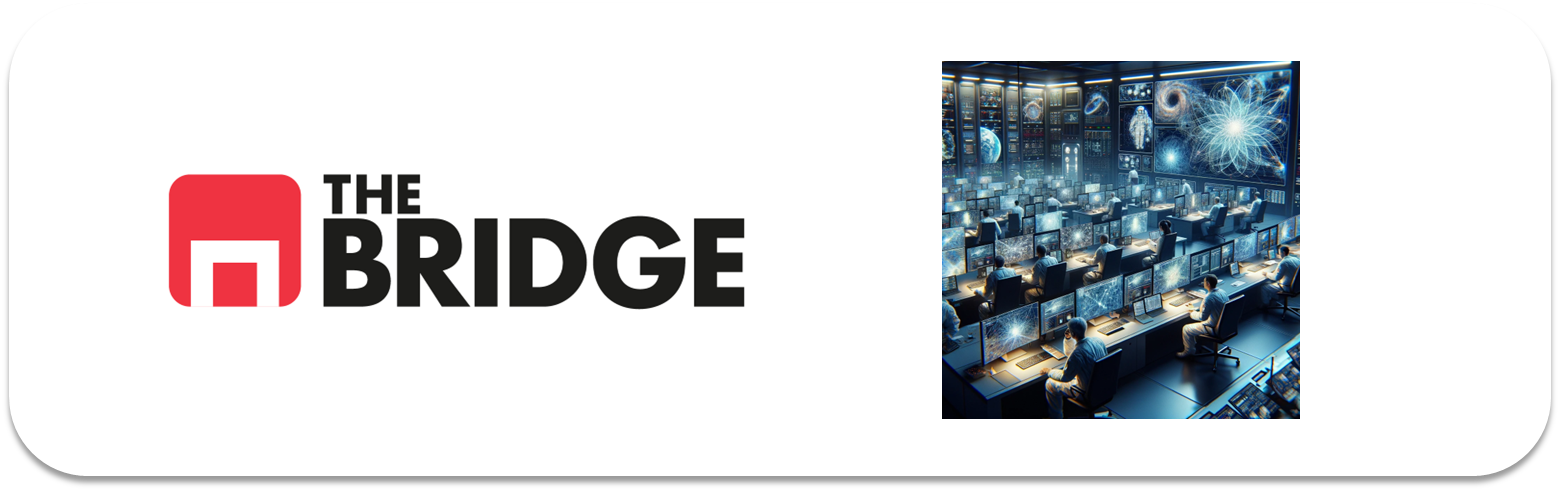

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [1]:
import os
import cv2
import numpy as np
import pandas as pd

In [2]:
# Función para obtener la etiqueta desde el nombre del archivo

def get_label_from_filename(filename):
    fname = filename.lower()
    if "dog" in fname:
        return 1   # perro
    elif "cat" in fname:
        return 0   # gato
    else:
        raise ValueError(f"No se detecta clase en el nombre del archivo: {filename}")


In [3]:
# Función para leer imágenes, redimensionarlas y normalizarlas

IMG_SIZE = 32

def load_images_from_dirs(base_path, dir_list):
    X = []
    y = []

    for d in dir_list:
        full_dir = os.path.join(base_path, d)

        for fname in os.listdir(full_dir):
            fpath = os.path.join(full_dir, fname)

            # Leer imagen
            img = cv2.imread(fpath)
            if img is None:
                continue

            # Convertir BGR → RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Redimensionar a 32x32
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Normalización a [0,1]
            img = img.astype("float32") / 255.0

            # Etiqueta desde el nombre del archivo
            label = get_label_from_filename(fname)

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)


In [4]:
# Directorios

base_path = "data"

train_dirs = ["github_train_0", "github_train_1", "github_train_2", "github_train_3"]

test_dirs  = ["github_test"]


In [5]:
# Creamos los datasets

X_train, y_train = load_images_from_dirs(base_path, train_dirs)
X_test, y_test   = load_images_from_dirs(base_path, test_dirs)


In [6]:
print("Train:", X_train.shape, y_train.shape)
print("Test:",  X_test.shape,  y_test.shape)

print("Clases en train:", np.unique(y_train, return_counts=True))
print("Clases en test:",  np.unique(y_test, return_counts=True))


Train: (4000, 32, 32, 3) (4000,)
Test: (1000, 32, 32, 3) (1000,)
Clases en train: (array([0, 1]), array([2000, 2000]))
Clases en test: (array([0, 1]), array([500, 500]))


In [ ]:
# MiniEDA

In [8]:
# Verificar valores de los píxeles (normalización correcta)

print("Min pixel:", X_train.min())
print("Max pixel:", X_train.max())


Min pixel: 0.0
Max pixel: 1.0


In [7]:
# Dimensiones y estructura del dataset

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (4000, 32, 32, 3)
y_train: (4000,)
X_test: (1000, 32, 32, 3)
y_test: (1000,)


In [9]:
# Distribución de las clases

unique, counts = np.unique(y_train, return_counts=True)
print("Distribución en train:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("Distribución en test:", dict(zip(unique, counts)))

Distribución en train: {np.int64(0): np.int64(2000), np.int64(1): np.int64(2000)}
Distribución en test: {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}


In [10]:
# Visualización de algunas imágenes

import matplotlib.pyplot as plt

def plot_images(images, labels=None, n_cols=5):
    n_rows = (len(images) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))

    for i, img in enumerate(images):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        if labels is not None:
            plt.title("Perro" if labels[i] == 1 else "Gato")

    plt.tight_layout()
    plt.show()


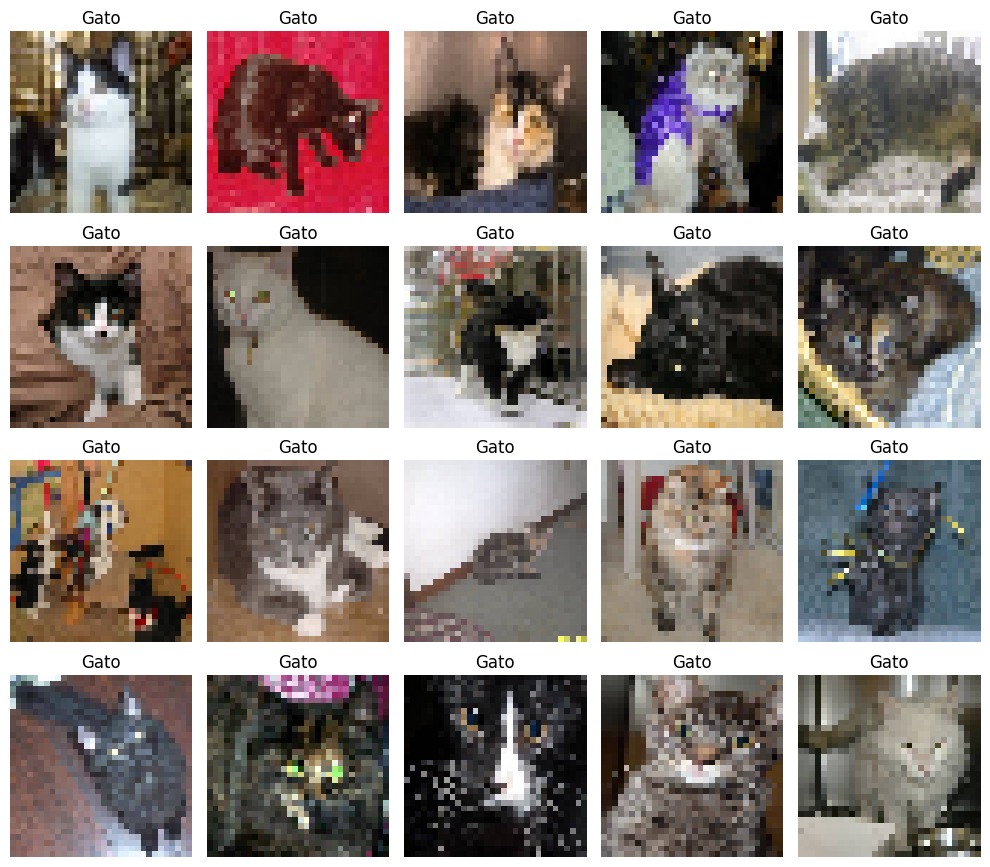

In [11]:
plot_images(X_train[:20], y_train[:20])

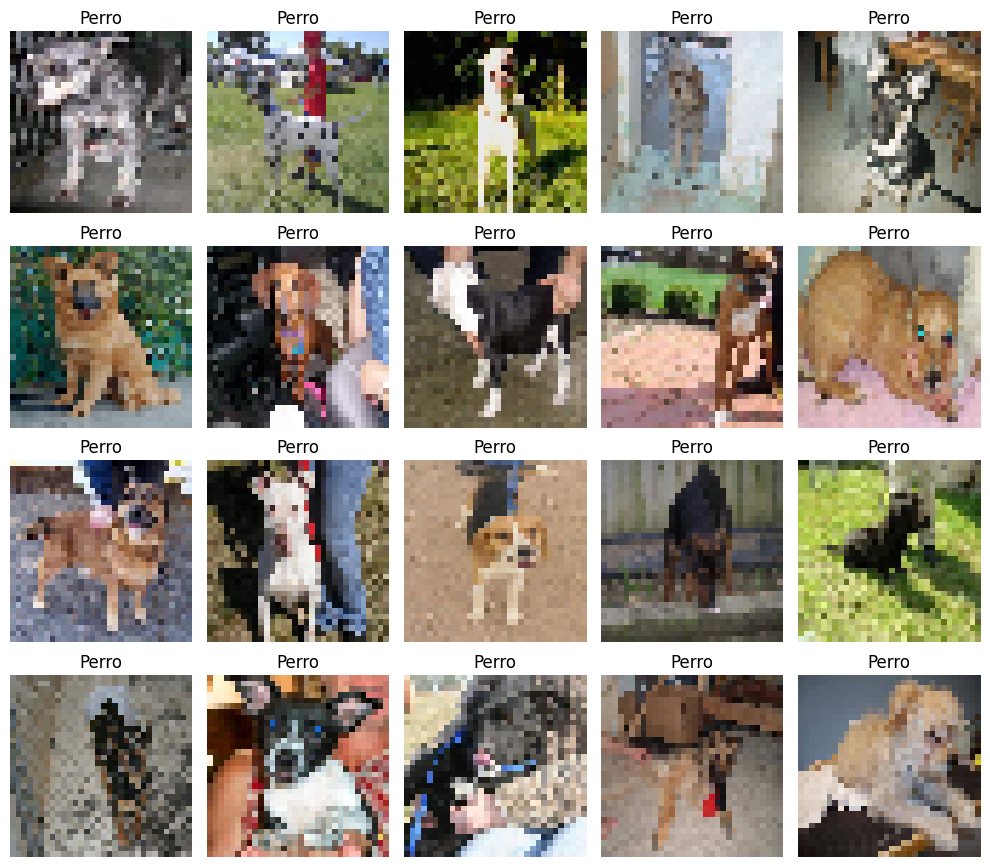

In [12]:
plot_images(X_train[2000:2020], y_train[2000:2020])


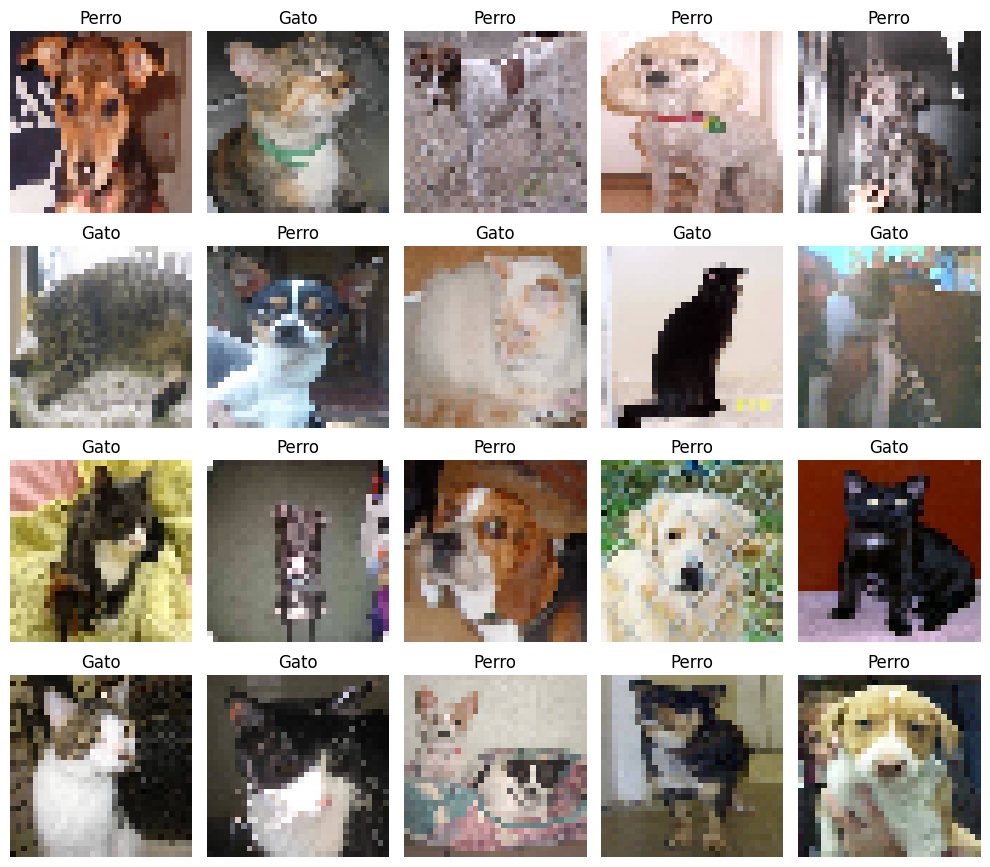

In [ ]:
# Comprobación de variabilidad

idxs = np.random.randint(0, len(X_train), 20)
plot_images(X_train[idxs], y_train[idxs])


In [18]:
from keras import layers, models

model = models.Sequential([

    # Capa de entrada explícita
    layers.Input(shape=(32, 32, 3)),

    # Bloque 1
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Bloque 2
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Bloque 3 (extra para mejorar capacidad)
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Clasificación
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])


In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Modelo CNN con al menos dos bloques Conv+Pool

from tensorflow.keras import layers, models, optimizers

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(1, activation='sigmoid'))  # binaria: perro/gato

optimizer = optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,041 (621.25 KB)

 Trainable params: 159,041 (621.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, batch_size = batch_size, epochs= epochs, validation_split= validation_split)

In [ ]:
# Entrenar con EarlyStopping y mostrar history

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # validación del 20%
    callbacks=[early_stop]
)


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6234 - loss: 0.6640 - val_accuracy: 0.0000e+00 - val_loss: 1.0171
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6416 - loss: 0.6350 - val_accuracy: 0.0288 - val_loss: 1.2215
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6828 - loss: 0.5890 - val_accuracy: 0.7563 - val_loss: 0.5460
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7078 - loss: 0.5637 - val_accuracy: 0.5075 - val_loss: 0.7465
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7337 - loss: 0.5278 - val_accuracy: 0.4475 - val_loss: 0.8784
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7716 - loss: 0.4920 - val_accuracy: 0.5400 - val_loss: 0.8183
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7966 - loss: 0.4360 - val_accuracy: 0.6775 - val_loss: 0.6455
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8281 - loss: 0.3794 - val_

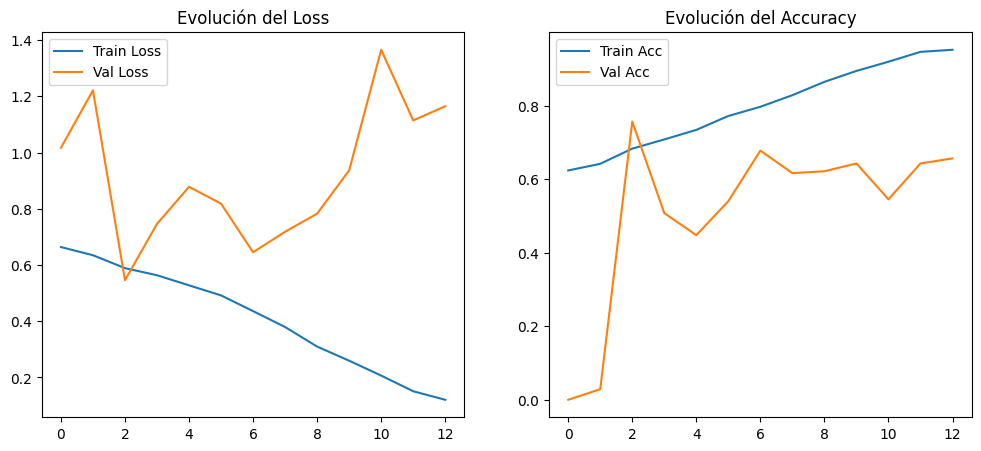

In [6]:
# Gráficas

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Evolución del Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Evolución del Accuracy')

plt.show()

Loss test: 0.6012611985206604
Accuracy test: 0.6700000166893005
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

        gato       0.71      0.57      0.63       500
       perro       0.64      0.77      0.70       500

    accuracy                           0.67      1000
   macro avg       0.68      0.67      0.67      1000
weighted avg       0.68      0.67      0.67      1000



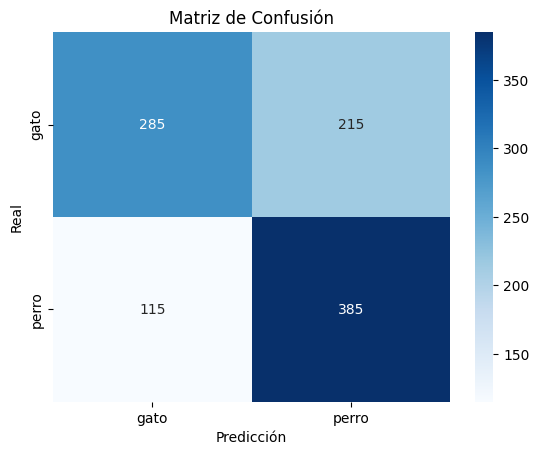

In [7]:
# Evaluar, classification report y matriz de confusión

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Loss test:", test_loss)
print("Accuracy test:", test_acc)

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").ravel()

print(classification_report(y_test, y_pred, target_names=["gato", "perro"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["gato","perro"],
            yticklabels=["gato","perro"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()
